In [13]:
import os
import sys
import json
sys.path.append('/home/ldy/Closed_loop_optimizing/experiments')
# from util import plot_similarity_and_mse_with_dual_axis
import numpy as np
import matplotlib.pyplot as plt

In [14]:


def plot_similarity_and_mse_with_dual_axis(similarities_per_iteration, save_folder, target_similarity=1.0, title='Similarity_and_MSE_Dual_Axis.png'):
    """
    绘制相似度和根据相似度计算的MSE曲线，带误差带，使用双坐标轴，并调整外框线宽。
    
    Args:
        similarities_per_iteration (list): 每轮迭代中的相似度列表，形状为 [iterations, num_images_per_iteration]
        save_folder (str): 保存图片的文件夹路径
        target_similarity (float, optional): 目标相似度，用于计算MSE，默认为1.0（表示完全相似）
    """
    # 数据预处理
    num_iterations = len(similarities_per_iteration)
    iterations = range(1, num_iterations + 1)
    
    # 计算统计量
    avg_similarities = [np.mean(s) for s in similarities_per_iteration]
    max_similarities = [np.max(s) for s in similarities_per_iteration]
    min_similarities = [np.min(s) for s in similarities_per_iteration]
    
    # 计算MSE（基于max_similarities）
    mse_per_iteration = [(sim - target_similarity)**2 for sim in max_similarities]
    
    # 创建图形和坐标轴
    fig, ax1 = plt.subplots(figsize=(12, 8))
    
    # 绘制相似度曲线（左轴）
    ax1.fill_between(iterations, min_similarities, max_similarities, 
                    color='lightblue', alpha=0.3, label='Similarity Range')
    ax1.plot(iterations, avg_similarities, color='blue', 
            linewidth=2, label='Avg Similarity')
    ax1.set_xlabel('Iteration', fontsize=30)
    ax1.set_ylabel('Similarity', fontsize=30)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # 创建右轴并绘制MSE曲线
    ax2 = ax1.twinx()
    ax2.plot(iterations, mse_per_iteration, color='red', 
            linewidth=2, linestyle='--', label='MSE')
    ax2.set_ylabel('MSE', fontsize=30)
    
    # 样式调整
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.tick_params(axis='both', which='major', labelsize=25)
    
    # 合并图例
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, 
              loc='upper center', fontsize=25, ncol=3,
              bbox_to_anchor=(0.5, 1.15),
              frameon=False)
    
    # 保存和显示
    plt.tight_layout()
    save_path = os.path.join(save_folder, title)
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Saved to: {save_path}")
    plt.show()
    plt.close()

In [15]:
def load_similarities_json(save_folder, filename="similarities.json"):
    filepath = os.path.join(save_folder, filename)
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"File {filepath} not found")
        return None


Saved to: /mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/outputs/Interactive_search_plot.png


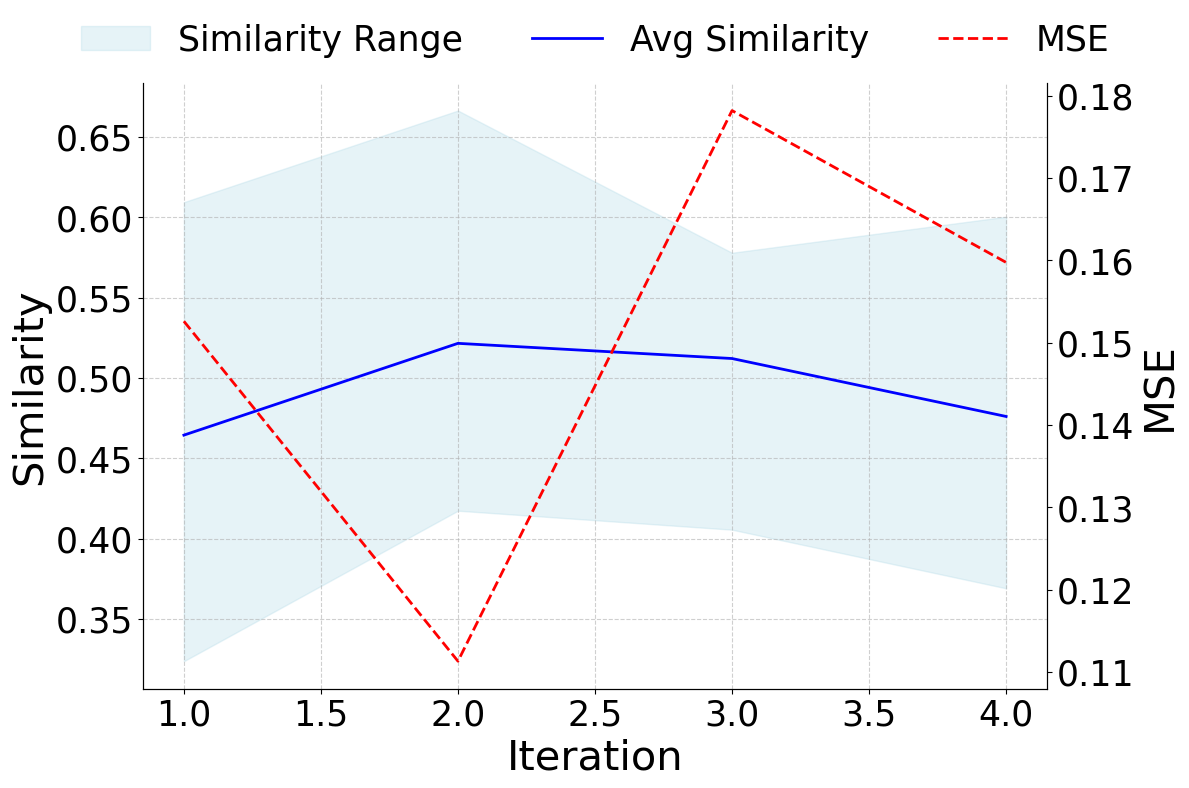

In [19]:
plots_save_folder = '/home/ldy/Closed_loop_optimizing/plots/Interactive_search'
save_folder = f'/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/outputs'


similarities_per_iteration = load_similarities_json(plots_save_folder, filename="Interactive_search2.json") 
plot_similarity_and_mse_with_dual_axis(similarities_per_iteration, save_folder, target_similarity=1.0, title="Interactive_search_plot.png")

Saved to: /mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/outputs/Multi_Target_Comparison.png


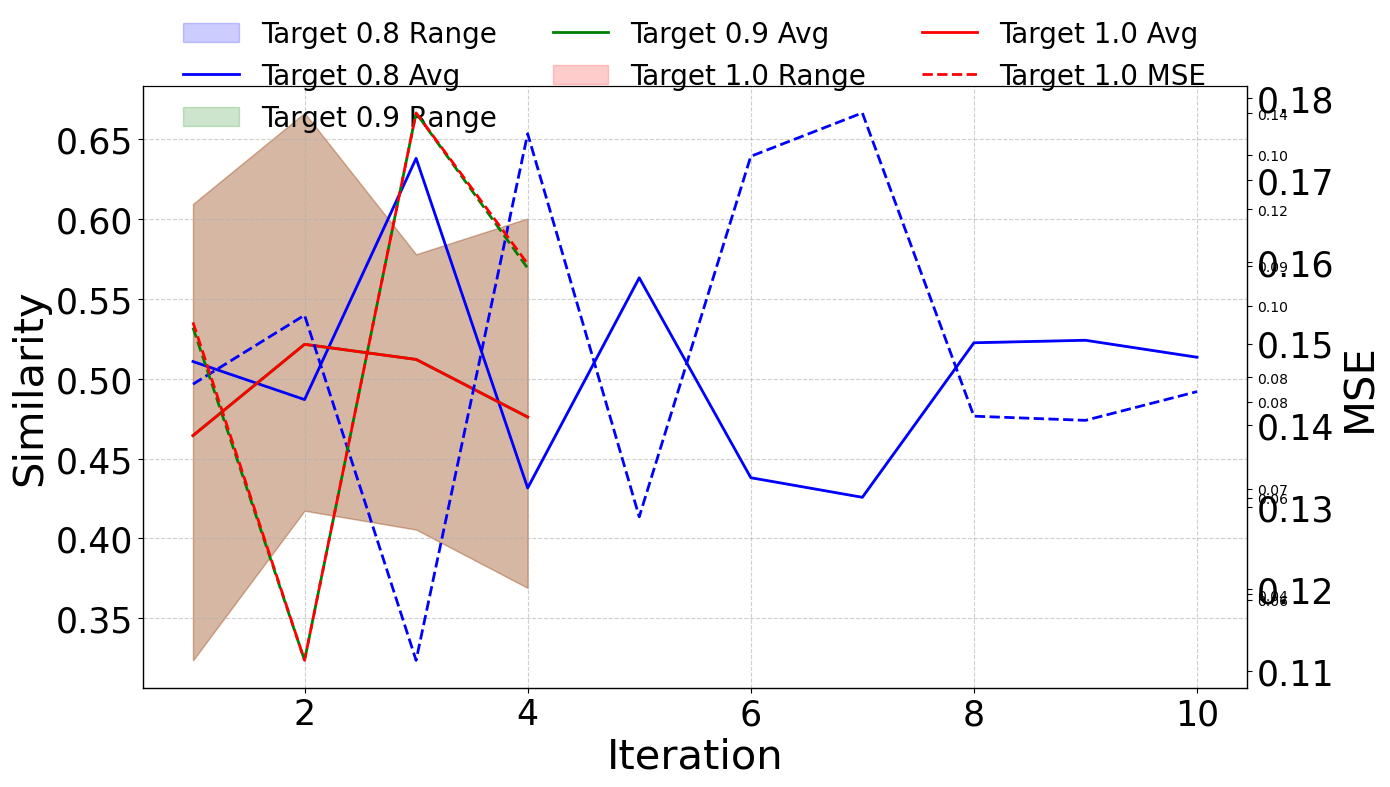

In [ ]:
# def plot_multiple_similarity_mse_comparison(similarities_list, save_folder, targets, colors, title='Multi_Target_Comparison.png'):
#     """
#     Plot comparison of multiple similarity and MSE curves with dual axes, 
#     handling datasets of different lengths.
    
#     Args:
#         similarities_list (list of lists): List containing multiple similarities_per_iteration datasets
#         save_folder (str): Folder to save the plot
#         targets (list): List of target similarity values for each dataset
#         colors (list): List of colors for each dataset
#         title (str): Output filename
#     """
#     # Verify inputs
#     assert len(similarities_list) == len(targets) == len(colors), "Input lists must have same length"
    
#     num_datasets = len(similarities_list)
    
#     # Create figure and axes
#     fig, ax1 = plt.subplots(figsize=(14, 8))
    
#     # Plot each dataset
#     for i in range(num_datasets):
#         similarities = similarities_list[i]
#         target = targets[i]
#         color = colors[i]
        
#         # Calculate statistics
#         avg_similarities = [np.mean(s) for s in similarities]
#         max_similarities = [np.max(s) for s in similarities]
#         min_similarities = [np.min(s) for s in similarities]
        
#         # Create x-axis values based on actual data length
#         iterations = range(1, len(similarities) + 1)
        
#         # Plot similarity (left axis)
#         ax1.fill_between(iterations, min_similarities, max_similarities, 
#                         color=color, alpha=0.2, label=f'Target {target} Range')
#         ax1.plot(iterations, avg_similarities, color=color, 
#                 linewidth=2, label=f'Target {target} Avg')
        
#         # Plot MSE on right axis (need to create here to keep colors aligned)
#         ax2 = ax1.twinx()
#         mse_per_iteration = [(sim - target)**2 for sim in max_similarities]
#         ax2.plot(iterations, mse_per_iteration, color=color,
#                 linewidth=2, linestyle='--', label=f'Target {target} MSE')
    
#     # Set up axes
#     ax1.set_xlabel('Iteration', fontsize=30)
#     ax1.set_ylabel('Similarity', fontsize=30)
#     ax1.grid(True, linestyle='--', alpha=0.6)
#     ax2.set_ylabel('MSE', fontsize=30)
    
#     # Style adjustments
#     for ax in [ax1, ax2]:
#         ax.spines['top'].set_visible(False)
#         ax.tick_params(axis='both', which='major', labelsize=25)
    
#     # Combine legends
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines1 + lines2, labels1 + labels2, 
#               loc='upper center', fontsize=20, ncol=3,
#               bbox_to_anchor=(0.5, 1.15),
#               frameon=False)
    
#     # Save and show
#     plt.tight_layout()
#     save_path = os.path.join(save_folder, title)
#     plt.savefig(save_path, bbox_inches='tight', dpi=300)
#     print(f"Saved to: {save_path}")
#     plt.show()
#     plt.close()

# # Example usage:
# similarities_target1 = load_similarities_json(plots_save_folder, "Interactive_search.json")
# similarities_target2 = load_similarities_json(plots_save_folder, "Interactive_search2.json")
# similarities_target3 = load_similarities_json(plots_save_folder, "Interactive_search2.json")

# plot_multiple_similarity_mse_comparison(
#     similarities_list=[similarities_target1, similarities_target2, similarities_target3],
#     save_folder=save_folder,
#     targets=[0.8, 0.9, 1.0],
#     colors=['blue', 'green', 'red'],
#     title="Multi_Target_Comparison.png"
# )